# OULAD pipeline Another approach

## 1. Setup

In [69]:
%pip install networkx matplotlib
%pip install pyvis  # interactive graphs
%pip install torch-geometric  # for GNN later


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [1]:

# ============================================
# OULAD Cross-Course Evaluation
# Week 2 / 4 / 6 / 8
# ============================================


import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    balanced_accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


## Reproducible paths

In [17]:
from pathlib import Path

# Get the current notebook directory
BASE_DIR = Path.cwd()  # In notebooks
# For scripts: BASE_DIR = Path(__file__).resolve().parent

print(BASE_DIR)

# Define standard folders relative to the project root
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

# Example file path
input_file = RAW_DIR / "studentInfo.csv"
Input_file = RAW_DIR / "studentVle.csv"
Input_file = RAW_DIR / "studentAssessment.csv"
Input_file = RAW_DIR / "assessments.csv"

print(f"Data directory: {input_file}")

# Create directories if they don't exist
for path in [DATA_DIR, RAW_DIR, PROCESSED_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Directories ready    at:")
print(f"Data directory: {DATA_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

from pathlib import Path
import pandas as pd

# Using Configured path
# Ensure Config exists for downstream cells
class Config:
    RAW_DIR = RAW_DIR
    OUTPUT_DIR = OUTPUT_DIR

studentInfo_path = Config.RAW_DIR / "studentInfo.csv"
studentVle_path = Config.RAW_DIR / "studentVle.csv"
studentAssessment_path = Config.RAW_DIR / "studentAssessment.csv"
assessments_path = Config.RAW_DIR / "assessments.csv"

c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding
Data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentInfo.csv
Directories ready    at:
Data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data
Raw data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw
Processed data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\processed
Output directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\outputs


## 3. Load preprocessed data

In [18]:
# Using configured path already available in the notebook
if "Config" not in globals():
    class Config:
        RAW_DIR = RAW_DIR

studentInfo_path = Config.RAW_DIR / "studentInfo.csv"
studentVle_path = Config.RAW_DIR / "studentVle.csv"
studentAssessment_path = Config.RAW_DIR / "studentAssessment.csv"
assessments_path = Config.RAW_DIR / "assessments.csv"

# Check if files exist
for file_path in [studentInfo_path, studentVle_path, studentAssessment_path, assessments_path]:
    if not file_path.exists():
        print(f"Warning: {file_path} does not exist.")
    else:
        print(f"Found: {file_path}")

# Build a dictionary of available dataframes (without shadowing `datasets`)
loaded_datasets = {}

if "student_info" in globals():
    loaded_datasets["student_info"] = student_info
if "student_assess" in globals():
    loaded_datasets["student_assess"] = student_assess
if "assessments" in globals():
    loaded_datasets["assessments"] = assessments
if "courses" in globals():
    loaded_datasets["courses"] = courses

for name, df_ in loaded_datasets.items():
    print(f"\n{name}")
    print(f"Shape: {df_.shape}")

    if df_.empty:
        print("WARNING: Dataset is empty")
    else:
        print("Loaded successfully")
print(f"Data directory: {Config.RAW_DIR}")
print(f"Output directory: {Config.OUTPUT_DIR}")


Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentInfo.csv
Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentVle.csv
Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\studentAssessment.csv
Found: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw\assessments.csv
Data directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\data\raw
Output directory: c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\outputs


## 4. Define risk

In [21]:
# Binary risk:
# 1 = at-risk (Fail/Withdrawn)
# 0 = success (Pass/Distinction)
# Ensure `student_info` exists
if "student_info" not in globals():
    if studentInfo_path.exists():
        student_info = pd.read_csv(studentInfo_path)
    else:
        raise FileNotFoundError(f"Missing file: {studentInfo_path}")

# Validate required column
if "final_result" not in student_info.columns:
    raise KeyError("'final_result' column not found in student_info")

# Create binary target
student_info["target"] = student_info["final_result"].apply(
    lambda x: 1 if x in ["Fail", "Withdrawn"] else 0
)

# Keep `df` available for downstream cells if not already defined
if "df" not in globals():
    df = student_info.copy()
counts = student_info['target'].value_counts()
counts.index = counts.index.map({1: 'At-risk (1)', 0: 'Low-risk (0)'})

counts_df = counts.reset_index()
counts_df.columns = ["Category", "Count"]

# Add percentage
counts_df["Percentage (%)"] = (counts_df["Count"] / counts_df["Count"].sum() * 100).round(2)

# To make sure the target is not missing in the main dataframe, we add it if it's not present
if "target" not in df.columns and "final_result" in df.columns:
    df["target"] = df["final_result"].apply(
        lambda x: 1 if x in ["Fail", "Withdrawn"] else 0
    )

display(counts_df)


,Category,Count,Percentage (%)
0,At-risk (1),17208,52.8
1,Low-risk (0),15385,47.2


## 5. Define prediction windows

In [22]:

# Week filtering
weeks = [2, 4, 6, 8]

def filter_week(df, week):
    return df[df["week"] <= week].copy()


## 6. Feature groups

In [23]:

demographic_cols = [
    "age_band",
    "num_of_prev_attempts",
    "studied_credits"
]

vle_cols = [
    "total_clicks",
    "unique_resources",
    "activity_days"
]

assessment_cols = [
    "num_assessments",
    "mean_score",
    "submission_rate"
]

feature_groups = {
    "demographics": demographic_cols,
    "vle": vle_cols,
    "assessment": assessment_cols,
    "combined": demographic_cols + vle_cols + assessment_cols
}


## 7. Define models

In [24]:

models = {
    "logreg": LogisticRegression(max_iter=10000),
    "rf": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    "xgb": xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    ,
        validate_parameters=(globals().__setitem__("lgb", __import__("lightgbm")) or True)),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE
     )  

}


## 8. Metrics functions

In [25]:

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    
    return {
        "AUROC": roc_auc_score(y_true, y_prob),
        "AUPRC": average_precision_score(y_true, y_prob),
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred)
    }


## 9 Random  (Basaeline)

In [26]:

def run_random_split(df, features, model, week):
    
    df_w = filter_week(df, week)
    
    X = df_w[features]
    y = df_w["at_risk"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2
    )

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    
    metrics = compute_metrics(y_test, y_prob)
    metrics["week"] = week
    
    return metrics


## 10. LCPO Split (Core contribution)

In [27]:

def run_lcpo(df, features, model, week):
    
    df_w = filter_week(df, week)
    
    X = df_w[features]
    y = df_w["at_risk"]
    
    groups = df_w["code_module"] + "_" + df_w["code_presentation"]
    
    gkf = GroupKFold(n_splits=len(groups.unique()))
    
    results = []
    
    for train_idx, test_idx in gkf.split(X, y, groups):
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:,1]

        metrics = compute_metrics(y_test, y_prob)
        
        metrics["week"] = week
        metrics["test_course"] = groups.iloc[test_idx].iloc[0]

        results.append(metrics)

    return pd.DataFrame(results)


## 11. Main experiment loop

Feature preparation with string fix

In [47]:

def clean_feature_names(df):
    df.columns = (
        df.columns
        .str.replace(r"[^\w]", "_", regex=True)   # keep only letters/numbers/_
        .str.replace(r"_+", "_", regex=True)      # remove duplicate underscores
        .str.strip("_")                           # trim edges
    )
    return df


def prepare_features(df, feature_cols):
    X = df[feature_cols].copy()

    # Detect categorical columns
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    # One-hot encoding
    if len(cat_cols) > 0:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

    # Clean feature names for XGBoost compatibility
    X = clean_feature_names(X)

    # Ensure numeric
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    return X


Random split

In [48]:

def run_random_split(df, features, model, week):
    
    df_w = filter_week(df, week)

    X = prepare_features(df_w, features)
    y = df_w["at_risk"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        stratify=y,
        test_size=0.2,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = compute_metrics(y_test, y_prob)
    metrics["week"] = week

    return metrics


LCPO Split (Cross-course) (IMplementation for this part)

In [49]:

def run_lcpo(df, features, model, week):
    
    df_w = filter_week(df, week)

    groups = df_w["code_module"] + "_" + df_w["code_presentation"]

    X = prepare_features(df_w, features)
    y = df_w["at_risk"]

    gkf = GroupKFold(n_splits=len(groups.unique()))

    results = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

        metrics = compute_metrics(y_test, y_prob)
        metrics["week"] = week
        metrics["test_course"] = groups.iloc[test_idx].iloc[0]

        results.append(metrics)

    return pd.DataFrame(results)


Main Loop 

In [50]:

overall_results = []
course_results = []

for week in weeks:
    
    print(f"\n==============================")
    print(f"RUNNING WEEK {week}")
    print(f"==============================")
    
    for group_name, features in feature_groups.items():
        
        required_cols = set(features + ["at_risk", "code_module", "code_presentation", "week"])
        missing_cols = [c for c in required_cols if c not in df.columns]
        
        if missing_cols:
            print(f"Skipping group={group_name} (missing {missing_cols})")
            continue
        
        for model_name, model in models.items():
            
            print(f"▶ week={week} | group={group_name} | model={model_name}")
            
            try:
                # RANDOM SPLIT
                res = run_random_split(df, features, model, week)
                res["split"] = "random"
                res["model"] = model_name
                res["feature_group"] = group_name
                overall_results.append(res)

                # LCPO SPLIT
                lcpo_df = run_lcpo(df, features, model, week)
                lcpo_df["split"] = "lcpo"
                lcpo_df["model"] = model_name
                lcpo_df["feature_group"] = group_name
                course_results.append(lcpo_df)

            except Exception as e:
                print("ERROR:")
                print(f"week={week}, group={group_name}, model={model_name}")
                print(str(e))
                continue



RUNNING WEEK 2
▶ week=2 | group=demographics | model=logreg


C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.py

▶ week=2 | group=demographics | model=rf


C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.py

▶ week=2 | group=demographics | model=xgb


...

▶ week=8 | group=demographics | model=XGBoost


C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
c:\Users\rq0016\Documents\Personal_2024_2025\phd_student_success\New_approach\Coding\stud_venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:10:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314

▶ week=8 | group=demographics | model=LightGBM
[LightGBM] [Info] Number of positive: 13766, number of negative: 12308
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.527959 -> initscore=0.111952
[LightGBM] [Info] Start training from score 0.111952
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\rq0016\AppData\Local\Temp\ipykernel_29808\3588990314.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.py

[LightGBM] [Info] Number of positive: 15725, number of negative: 14370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54
[LightGBM] [Info] Number of data points in the train set: 30095, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522512 -> initscore=0.090109
[LightGBM] [Info] Start training from score 0.090109
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

## 12.Save results

In [51]:

results_df = pd.DataFrame(overall_results)
course_df = pd.concat(course_results, ignore_index=True)

results_df.to_csv(RESULTS_DIR / "overall_results.csv", index=False)
course_df.to_csv(RESULTS_DIR / "per_course_results.csv", index=False)


## 13. Generalization Gap plot

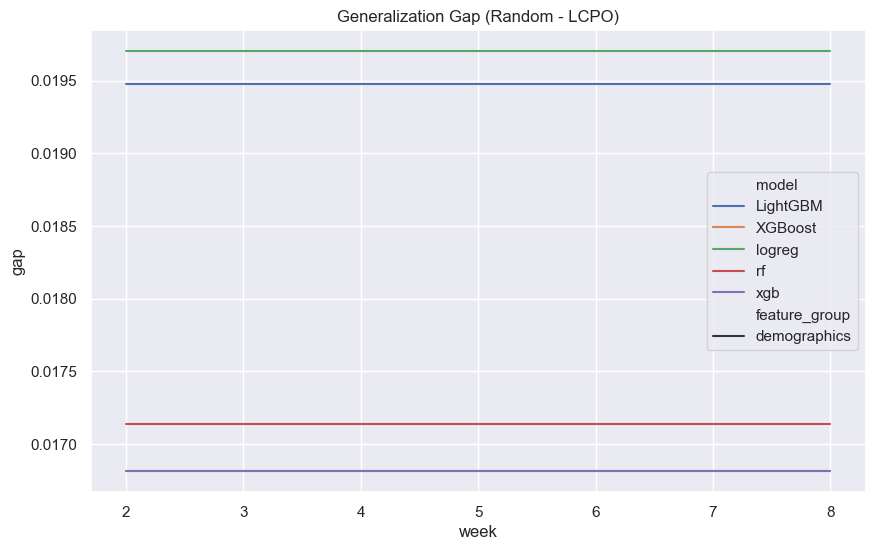

In [55]:

# Build random AUROC (from overall results)
random_df = (
    results_df[results_df["split"] == "random"]
    .groupby(["week", "model", "feature_group"], as_index=False)["AUROC"]
    .mean()
    .rename(columns={"AUROC": "random"})
)

# Build LCPO AUROC:
# Prefer results_df if lcpo exists there; otherwise use course_df (per-course) and average
if "split" in results_df.columns and (results_df["split"] == "lcpo").any():
    lcpo_df = (
        results_df[results_df["split"] == "lcpo"]
        .groupby(["week", "model", "feature_group"], as_index=False)["AUROC"]
        .mean()
        .rename(columns={"AUROC": "lcpo"})
    )
else:
    lcpo_df = (
        course_df[course_df["split"] == "lcpo"]
        .groupby(["week", "model", "feature_group"], as_index=False)["AUROC"]
        .mean()
        .rename(columns={"AUROC": "lcpo"})
    )

# Merge so both columns always exist
gap_df = random_df.merge(
    lcpo_df,
    on=["week", "model", "feature_group"],
    how="inner"
)
gap_df["gap"] = gap_df["random"] - gap_df["lcpo"]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=gap_df,
    x="week",
    y="gap",
    hue="model",
    style="feature_group"
)

plt.title("Generalization Gap (Random - LCPO)")
plt.show()


## 14. Course level Heat map

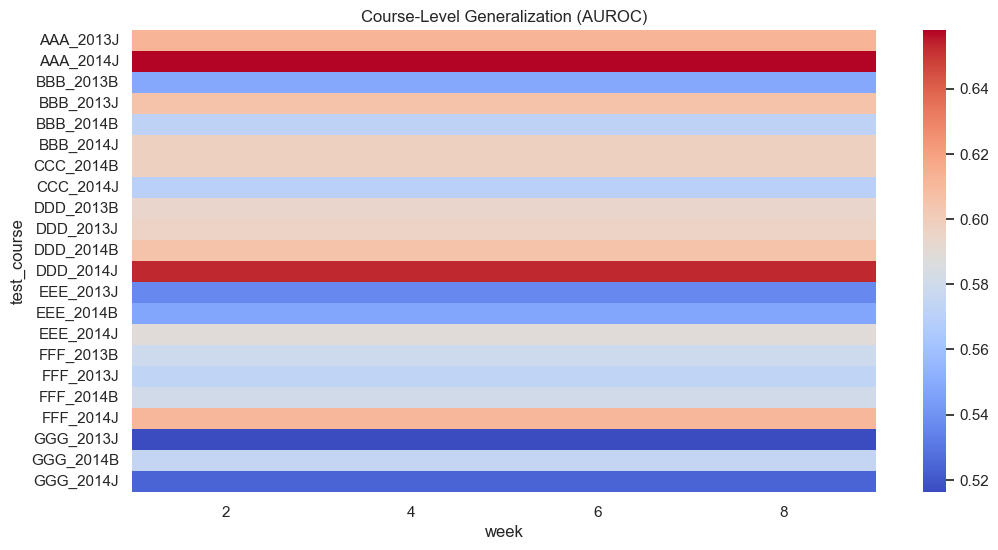

In [56]:

pivot = course_df.pivot_table(
    index="test_course",
    columns="week",
    values="AUROC"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Course-Level Generalization (AUROC)")
plt.show()


#  Graph construction and implementation 

In [70]:

# Ensure GRAPH_DIR exists (use existing OUTPUT_DIR from the notebook)
if "GRAPH_DIR" not in globals():
    GRAPH_DIR = OUTPUT_DIR / "graph"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)

student_nodes = df[[
    "id_student",
    "age_band",
    "num_of_prev_attempts",
    "studied_credits"
]].drop_duplicates()

student_nodes.to_csv(GRAPH_DIR / "nodes_student.csv", index=False)


### Course nodes

In [60]:

course_nodes = df[[
    "code_module",
    "code_presentation"
]].drop_duplicates()

course_nodes["course_id"] = (
    course_nodes["code_module"] + "_" + course_nodes["code_presentation"]
)

course_nodes.to_csv(GRAPH_DIR / "nodes_course.csv", index=False)


### Student -> Course edge

In [61]:

edges_enrollment = df[[
    "id_student",
    "code_module",
    "code_presentation"
]].drop_duplicates()

edges_enrollment["course_id"] = (
    edges_enrollment["code_module"] + "_" + edges_enrollment["code_presentation"]
)

edges_enrollment.to_csv(GRAPH_DIR / "edges_enrollment.csv", index=False)


### Student -> vle edge 

In [64]:
if "total_clicks" in df.columns:
    edges_vle = df[["id_student", "total_clicks", "week"]].copy()
else:
    if "student_vle" not in globals():
        if not studentVle_path.exists():
            raise FileNotFoundError(f"Missing file: {studentVle_path}")
        student_vle = pd.read_csv(studentVle_path)

    if "sum_click" not in student_vle.columns:
        raise KeyError("Neither 'total_clicks' in df nor 'sum_click' in student_vle.")

    tmp_vle = student_vle.copy()

    if "week" not in tmp_vle.columns:
        if "date" in tmp_vle.columns:
            tmp_vle["week"] = (tmp_vle["date"].clip(lower=0) // 7 + 1).astype(int)
        else:
            tmp_vle["week"] = 1

    edges_vle = (
        tmp_vle.groupby(["id_student", "week"], as_index=False)["sum_click"]
        .sum()
        .rename(columns={"sum_click": "total_clicks"})
    )

edges_vle.rename(columns={"total_clicks": "weight"}, inplace=True)

edges_vle.to_csv(GRAPH_DIR / "edges_student_vle.csv", index=False)


### Student -> Assessment edge

In [67]:
# Build Student -> Assessment edge robustly
if {"mean_score", "submission_rate", "week"}.issubset(df.columns):
    edges_assessment = df[
        ["id_student", "mean_score", "submission_rate", "week"]
    ].copy()
else:
    # Load studentAssessment if not already in memory
    if "student_assess" not in globals():
        if not studentAssessment_path.exists():
            raise FileNotFoundError(f"Missing file: {studentAssessment_path}")
        student_assess = pd.read_csv(studentAssessment_path)

    tmp_assess = student_assess.copy()

    # Build week
    if "week" not in tmp_assess.columns:
        if "date_submitted" in tmp_assess.columns:
            tmp_assess["week"] = (tmp_assess["date_submitted"].clip(lower=0) // 7 + 1).astype(int)
        elif "date" in tmp_assess.columns:
            tmp_assess["week"] = (tmp_assess["date"].clip(lower=0) // 7 + 1).astype(int)
        else:
            tmp_assess["week"] = 1

    # Ensure score exists
    if "score" not in tmp_assess.columns:
        raise KeyError("Neither df has assessment features nor student_assess has 'score'.")

    # Compute mean_score + submission_rate per student-week
    tmp_assess["submitted"] = tmp_assess["score"].notna().astype(int)
    edges_assessment = (
        tmp_assess.groupby(["id_student", "week"], as_index=False)
        .agg(
            mean_score=("score", "mean"),
            submission_rate=("submitted", "mean")
        )
        .fillna({"mean_score": 0.0, "submission_rate": 0.0})
    )

edges_assessment.to_csv(GRAPH_DIR / "edges_student_assessment.csv", index=False)


## Graph

Imports

In [71]:

import networkx as nx
import matplotlib.pyplot as plt

import pandas as pd


Load data

In [75]:
candidate_paths = [
    DATA_DIR / "oulad_student_course_week.csv",
    PROCESSED_DIR / "oulad_student_course_week.csv",
    RAW_DIR / "oulad_student_course_week.csv",
]

existing_path = next((p for p in candidate_paths if p.exists()), None)

if existing_path is not None:
    df = pd.read_csv(existing_path)
    print(f"Loaded: {existing_path}")
elif "df" in globals():
    print("File not found in expected folders. Using existing `df` already in memory.")
else:
    searched = "\n".join(str(p) for p in candidate_paths)
    raise FileNotFoundError(
        "Could not find 'oulad_student_course_week.csv'. Searched:\n" + searched
    )

df.head()


File not found in expected folders. Using existing `df` already in memory.


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,at_risk,week
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,0,2
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,0,2
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,1,2
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,0,2
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,0,2


Smaple set

In [76]:

# Small sample for visualization
df_sample = df.sample(n=200, random_state=42)
G = nx.Graph()

Student -> Course graph

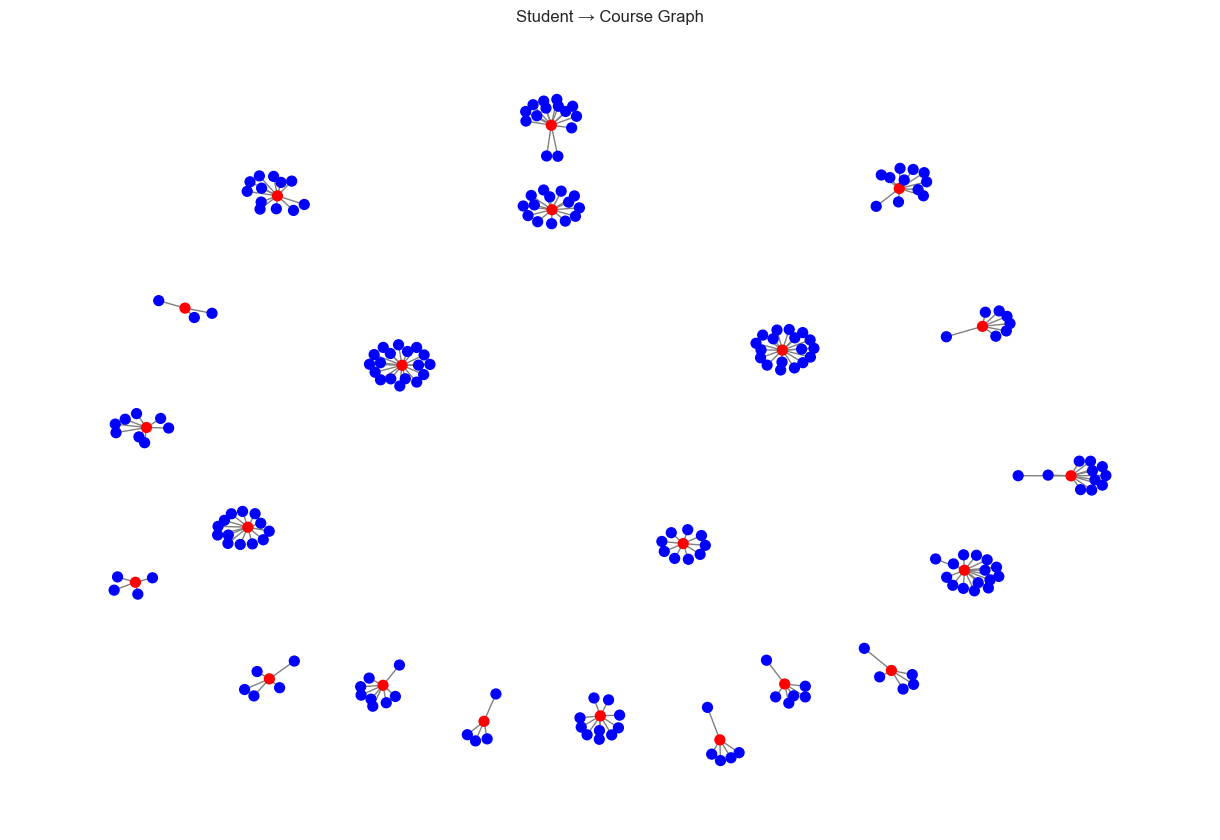

In [85]:

G_sc = nx.Graph()

for _, row in df_sample.iterrows():
    
    student = f"student_{row['id_student']}"
    course = f"course_{row['code_module']}_{row['code_presentation']}"
    
    G_sc.add_node(student, type="student")
    G_sc.add_node(course, type="course")
    
    G_sc.add_edge(student, course)
#plt.figure(figsize=(12, 36)) 
#nx.draw(G_sc, with_labels=True, node_size=500, node_color="lightblue")
#plt.title("Student-Course Enrollment Graph (Sample)")
#plt.show()

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G_sc, seed=42)

# Node colors
colors = [
    "blue" if G_sc.nodes[n]["type"] == "student" else "red"
    for n in G_sc.nodes()
]

nx.draw(G_sc, pos,
        node_color=colors,
        with_labels=False,
        node_size=50,
        edge_color="gray")

plt.title("Student → Course Graph")
plt.show()


Student -> VLE graph

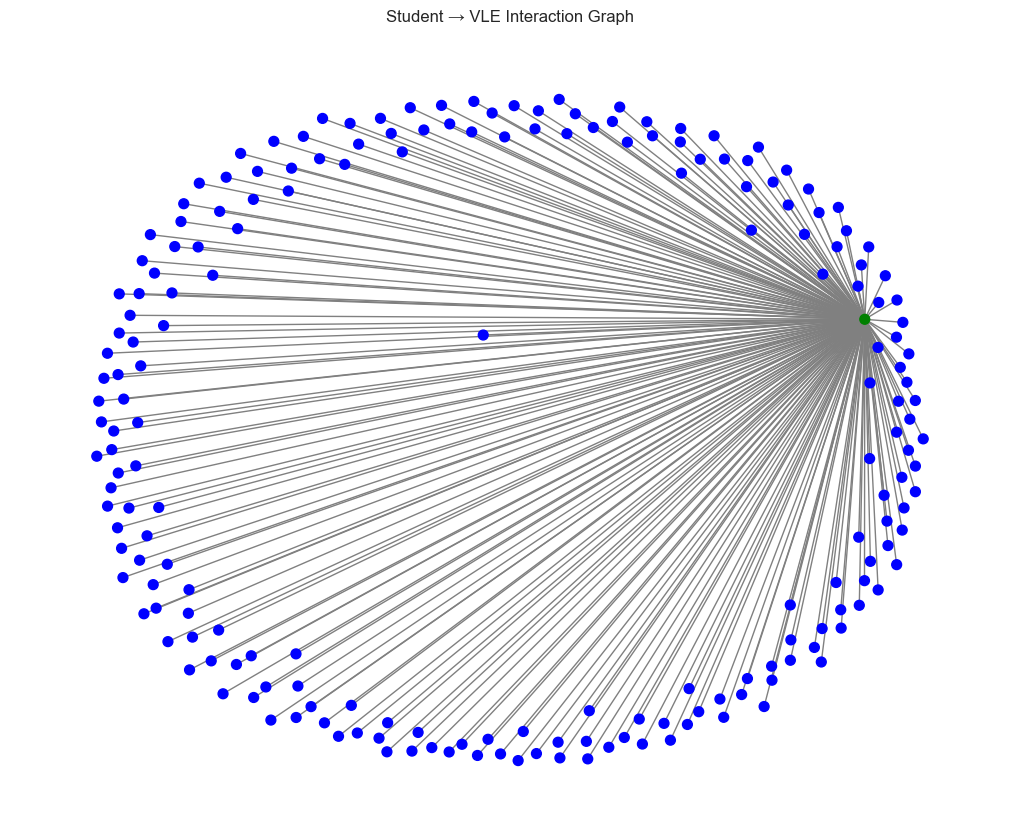

In [86]:


G_sv = nx.Graph()

for _, row in df_sample.iterrows():
    
    student = f"student_{row['id_student']}"
    vle_node = f"vle_week_{row['week']}"
    
    weight = row.get("total_clicks", 0)
    
    G_sv.add_node(student, type="student")
    G_sv.add_node(vle_node, type="vle")
    
    G_sv.add_edge(student, vle_node, weight=weight)


plt.figure(figsize=(10,8))

pos = nx.spring_layout(G_sv, seed=42)

colors = [
    "blue" if G_sv.nodes[n]["type"] == "student" else "green"
    for n in G_sv.nodes()
]

nx.draw(G_sv, pos,
        node_color=colors,
        with_labels=False,
        node_size=50,
        edge_color="gray")

plt.title("Student → VLE Interaction Graph")
plt.show()


Student -> Assessment graph

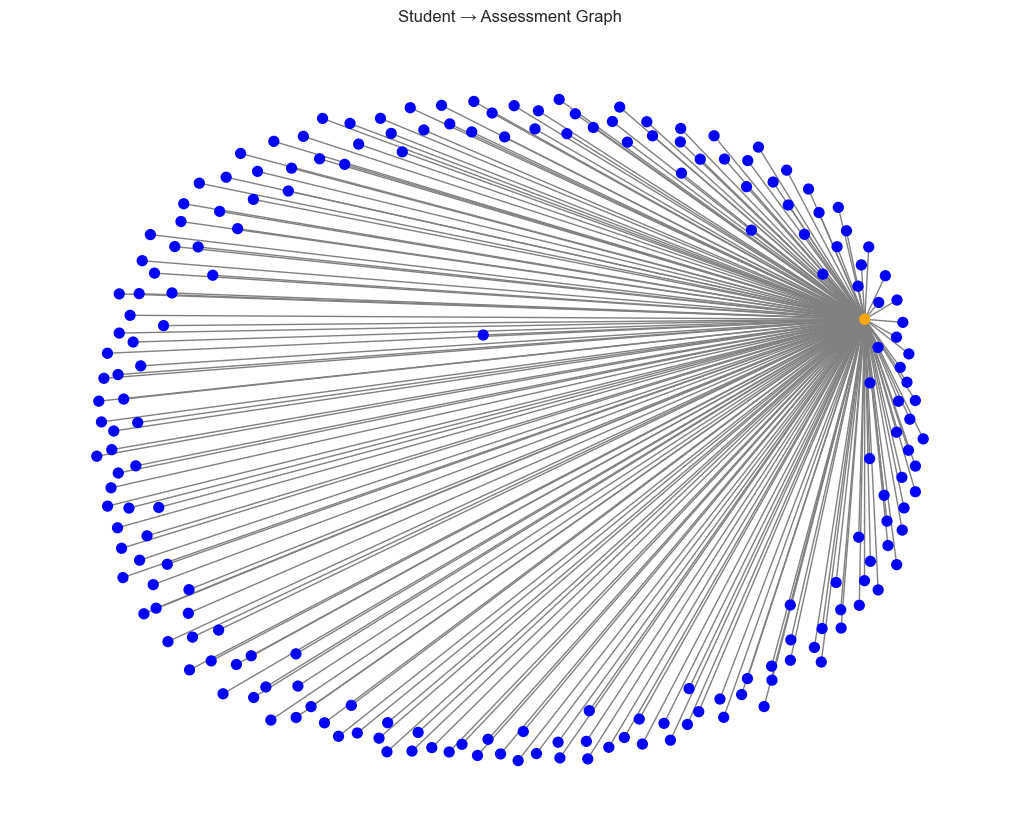

In [87]:

G_sa = nx.Graph()

for _, row in df_sample.iterrows():
    
    student = f"student_{row['id_student']}"
    assessment = f"assessment_week_{row['week']}"
    
    score = row.get("mean_score", 0)
    
    G_sa.add_node(student, type="student")
    G_sa.add_node(assessment, type="assessment")
    
    G_sa.add_edge(student, assessment, weight=score)


plt.figure(figsize=(10,8))

pos = nx.spring_layout(G_sa, seed=42)

colors = [
    "blue" if G_sa.nodes[n]["type"] == "student" else "orange"
    for n in G_sa.nodes()
]

nx.draw(G_sa, pos,
        node_color=colors,
        with_labels=False,
        node_size=50,
        edge_color="gray")

plt.title("Student → Assessment Graph")
plt.show()



Combined graph

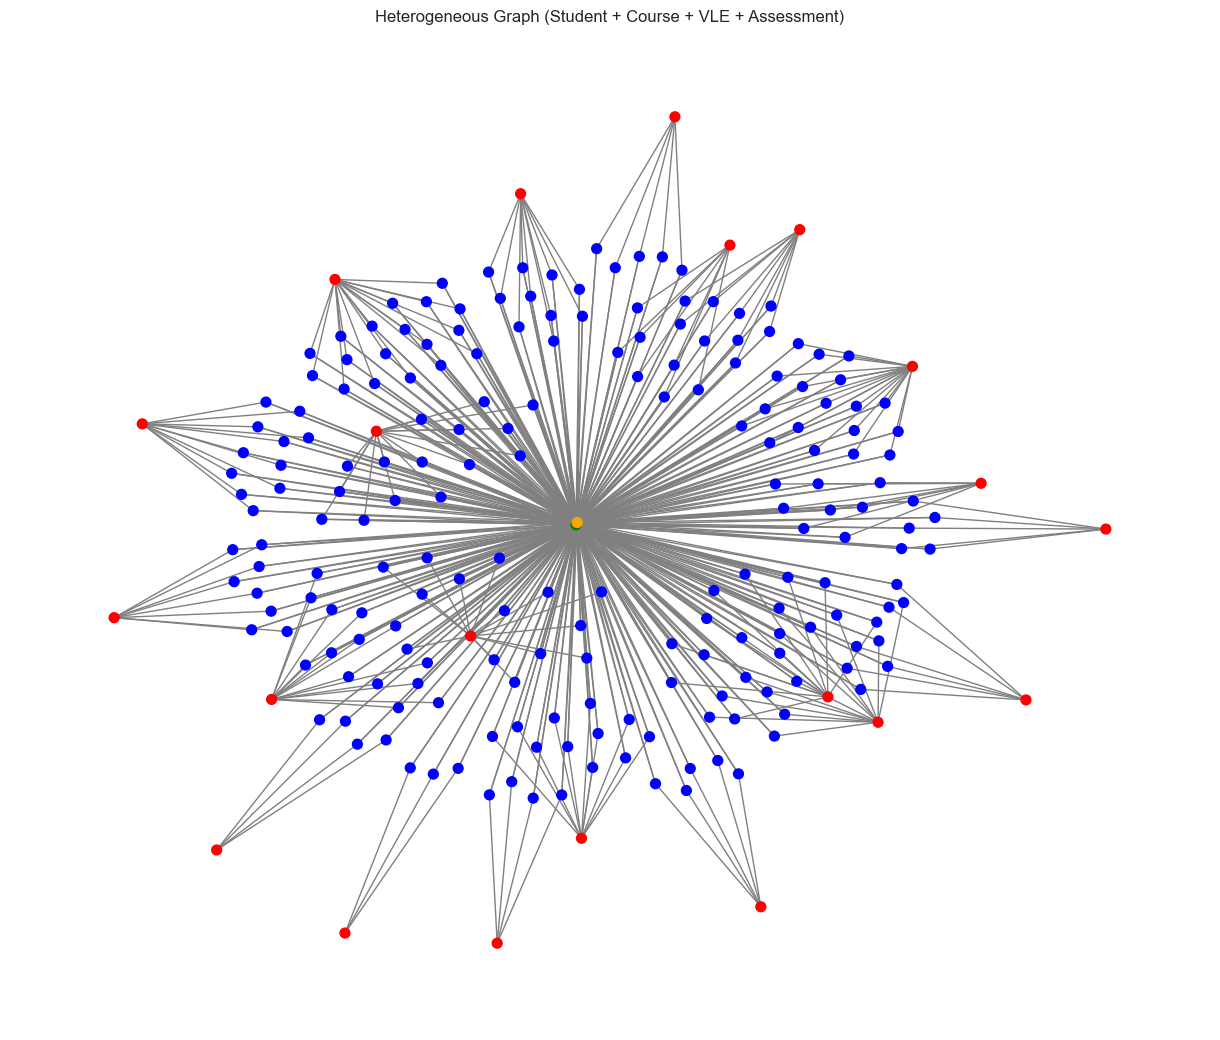

In [89]:

G_all = nx.Graph()

for _, row in df_sample.iterrows():
    
    student = f"student_{row['id_student']}"
    course = f"course_{row['code_module']}_{row['code_presentation']}"
    vle = f"vle_week_{row['week']}"
    assessment = f"assessment_week_{row['week']}"
    
    G_all.add_node(student, type="student")
    G_all.add_node(course, type="course")
    G_all.add_node(vle, type="vle")
    G_all.add_node(assessment, type="assessment")

    G_all.add_edge(student, course)
    G_all.add_edge(student, vle)
    G_all.add_edge(student, assessment)



plt.figure(figsize=(12,10))

pos = nx.spring_layout(G_all, seed=42)

color_map = {
    "student": "blue",
    "course": "red",
    "vle": "green",
    "assessment": "orange"
}

colors = [color_map[G_all.nodes[n]["type"]] for n in G_all.nodes()]

nx.draw(G_all, pos,
        node_color=colors,
        with_labels=False,
        node_size=50,
        edge_color="gray")

plt.title("Heterogeneous Graph (Student + Course + VLE + Assessment)")
plt.show()
